# Hidden Markov Models

Sequence models (in their simplest form) predicts next tokens from a vocabulary $\mathcal{V}$ of $n$ possible tokens conditioned on a prefix of older tokens. 

Language models are sequence models where the tokens are letters or substrings of text.

A simplest way to generate sequence dataset to model is via a Hidden Markov Model.

A (discrete) Hidden Markov Model is a discrete markov chain where true states of the markov model are hidden and only an observation sampled from $b_i(o)$ for the token $v_i \in \mathcal{V}$ is available.

This can be written as follows. 

$$z_{t+1} = Az_t, x_t = Bh_t$$

where $A, B$ are stochastic matrices.

In [48]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scienceplots

plt.style.use(["science", "no-latex"])


### Coin Toss Model

Suppose that there is a man flipping coins behind a wall. He has two biased coins which he switches in between (markovianly). Everytime he flips a coin he cals out whether the coin landed heads or tails. But he does not say what coin he flipped. 

This can be modeled as a Markov Chain where $A, B \in \mathbb{R}^{n\times n}$

In [49]:
b_1 = 0.6 # prob flip heads on coin 1
b_2 = 0.3 # prob flip heads on coin 2

a_11 = 0.7 # prob flipper remains on coin 1 each round
a_22 = 0.8 # prob flipper remains on coin 2 each round


A = np.array([
    [a_11, 1-a_22], 
    [1-a_11, a_22]   
])

B = np.array([
    [b_1  , b_2],    
    [1-b_1, 1-b_2]   
])


# Use the stationary distribution so X_0 is non-degenerate.
# A point-mass initial state (e.g. [1,0]) makes X_0 independent
# of all other observations, since Z_0 is already known with certainty.
eigenvalues, eigenvectors = np.linalg.eig(A)
stat_idx = np.argmin(np.abs(eigenvalues - 1.0))
pi_stationary = np.real(eigenvectors[:, stat_idx])
pi_stationary = pi_stationary / pi_stationary.sum()

pi_0 = pi_stationary
pi_0 = np.array([1.0, 0.0])

T = 15

for _ in range(4):
    states = [np.random.choice(2, p=pi_0)]
    obs = []
    for _ in range(T):
        o = np.random.choice(2, p=B[:,states[-1]])
        obs.append('H' if o == 0 else 'T')
        states.append(np.random.choice(2, p=A[:,states[-1]]))
    print(''.join(obs))

TTHTTTTHHTTHTTT
THHTTTTTHHTHHHT
THHTHHHHTTTTHHT
THTTTTHTTHHTTHH


### Properties of Sequences - Next/Prev Token Mutual Information

Now that we have a process to generate 'parameterized' sequences. We can ask some questions about what interesting statistics we can compute on these sequences. 

For example, I might ask: how much information does the previous token tell me about the next, and *importantly* how does this compare to the amount of information given by the next token. 

Why is this interesting? Well, if we are training an autoregressive model (like most language modelstoday) this tell us about whether we shuold model text from "left-to-right" or "right-to-left".

We can formalize this using the measure of "information" from information theory. Given two random variables $X, Y \sim p_{XY}$, the information $Y$ reveals about $X$ (or vice-versa since this is symmetric) is given by

$$
\begin{align*} 
    I(X; Y) &= D_{KL}(p_{XY}|| p_Xp_Y) \\ 
            &= H(X) - H(X|Y)
\end{align*}
$$


Fortunately, HMMs have structure that let's us analytically compute $$I(X_{j}; X_{k} | \mu = \pi_0)$$ where $\mu$ is the distribution of $X_0$.

First, we want to compute the joint ditribution of $(X_{j}, X_{k}) \sim p_{X_jX_k}$. We can do this by summing over the hidden marginal states

$$
\begin{align*}
P(X_j = a, X_k = b) &= \sum^{|\mathcal{H}|}_{i=1}\sum^{|\mathcal{H}|}_{\ell=1} P(Z_j = i, Z_k = \ell, X_j=a, X_k=b) \\
&= \sum_{i, \ell} P( X_k=b | Z_k = \ell, X_j=a, Z_j = i) P(Z_k = \ell | X_j=a, Z_j = i) P( X_j=a |Z_j=i) P(Z_j = i) \\
&= \sum_{i, \ell} P( X_k=b | Z_k = \ell) P(Z_k = \ell | Z_j = i)    P( X_j=a |Z_j=i)    P(Z_j = i) \\
&= \sum_{i, \ell}  (e_b^\top Be_\ell)     (e_\ell^\top A^{k-j} e_i)  ( e_a^\top B e_i) (e_i^\top A^j \mu) 
\end{align*}
$$

Here $e_i$ is the one-hot vector with 1 in the $i$-th element meaning $e_i^\top A e_j = A_{ij}$.

Using this joint, we can compute $I(X_j ; X_k)$ using the marginal formulation from above. 


In [50]:
import numpy as np
from numpy.linalg import matrix_power

def mutual_information_from_joint(p_XY: np.ndarray) -> float:

    assert p_XY.ndim == 2, "p_XY must be a 2D array"
    assert np.all((0 <= p_XY) & (p_XY <= 1)), "values must be in [0, 1]"
    assert np.isclose(p_XY.sum(), 1), "p_XY must sum to 1"

    p_X = p_XY.sum(axis=1)  # marginal over X (rows)
    p_Y = p_XY.sum(axis=0)  # marginal over Y (columns)

    p_X_p_Y = np.outer(p_X, p_Y)

    # mask for entries where both p_XY and p_Xp_Y > 0
    mask = (p_XY > 0) & (p_X_p_Y > 0)
    kl = np.sum(p_XY[mask] * np.log2(p_XY[mask] / p_X_p_Y[mask]))
    return float(kl)

def hmm_joint_distribution(A, B, mu, j, k):
    K, V = A.shape[1], B.shape[0] # num hidden states, num obs states
    assert A.shape == (K, K),          f"A must be ({K},{K}), got {A.shape}"
    assert B.shape == (V, K),          f"B must be (V,{K}), got {B.shape}"
    assert mu.shape == (K,),           f"mu must be ({K},), got {mu.shape}"
    assert np.isclose(A.sum(axis=0), 1).all(), "A must be column-stochastic"
    assert np.isclose(B.sum(axis=0), 1).all(), "B columns must sum to 1"
    assert np.isclose(mu.sum(), 1),    "mu must sum to 1"
    assert 0 <= j <= k,                "Must have 0 <= j <= k"

    state_at_j = matrix_power(A, j) @ mu            # (K,)  P(Z_j)
    joint = B * state_at_j                              # (V,K) P(X_j=a, Z_j=i)
    joint = matrix_power(A, k-j) @ joint.T             # (K,V) P(Z_k=l, X_j=a)
    joint = B @ joint                                   # (V,V) P(X_k=b, X_j=a)

    return joint

def hmm_mutual_information(A, B, mu, j, k):
    if j>k:
        j, k = k, j
    joint = hmm_joint_distribution(A, B, mu, j, k)
    minfo = mutual_information_from_joint(joint)
    return minfo

def hmm_entropy(A, B, mu, t):
    p_X_t = B @ matrix_power(A, t) @ mu
    # compute the entropy of the categorical given by p_X_t
    mask = p_X_t > 0
    entropy = -np.sum(p_X_t[mask] * np.log2(p_X_t[mask]))
    return float(entropy)


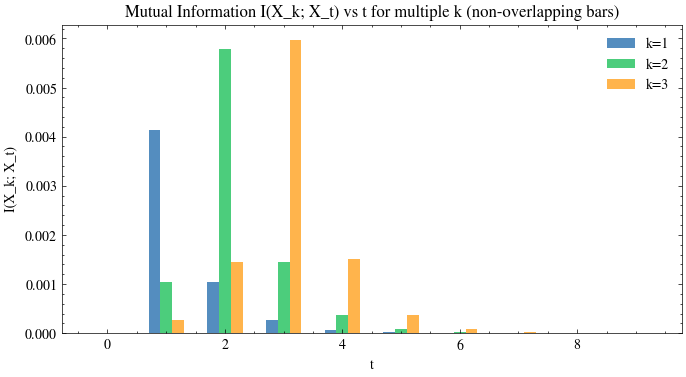

In [51]:
import matplotlib.pyplot as plt

ks = [1,2,3]
T = 10

# Assume mu, A, B are defined above and valid

mi_values = {}
ts = np.arange(T)
bar_width = 0.2  # width of each bar

for k in ks:
    mi_values[k] = []
    for t in ts:
        mi = hmm_mutual_information(A, B, pi_0, k, t)
        mi_values[k].append(mi)

plt.figure(figsize=(8, 4))
for i, k in enumerate(ks):
    offset = (i - (len(ks) - 1) / 2) * bar_width # so bars are centered around each t
    plt.bar(ts + offset, mi_values[k], width=bar_width, alpha=0.7, label=f"k={k}")
plt.xlabel("t")
plt.ylabel("I(X_k; X_t)")
plt.title("Mutual Information I(X_k; X_t) vs t for multiple k (non-overlapping bars)")
plt.legend()
plt.show()


Something that should be noted is that for many markov chains the behavior after large $T$ is predictable. Usually the state distribution at time $t$, $p_t$ will either 
1) Converge to a single "stationary" distribution
2) Oscillate
3) Have some behavior dependent on the initial condition.

In any case the marginal distributions of $X_t, X_{t+1}, X_{t+2}, ...$ becomes incresingly similar conditioned only on 
$X_0$ for large $t$. How quickly this becomes the case is called the "[mixing time](https://en.wikipedia.org/wiki/Markov_chain_mixing_time)" for a markov chain.


The mixing time is typically measured as the amount of time it takes for an initial distribution to be $\epsilon$ close to the stationary distribution using the total-variation distance ($d_{TV}(p, q) = \frac{1}{2}||p-q||_1$ ) *in the worst-case*.

We can write this as:
$$t_\text{mix}(\epsilon) = \min \left\{  t : \max_{\mu} d_{TV}(A^t\mu, \pi_{\text{stationary}} \leq \epsilon  )  \right\}$$

for some $\epsilon > 0$. Solving the optimization problem here can be hard, but we can get a bound based on the second largest eigenvalue of transition matrix $A$. 

ROUGH INTUITION: $\lambda_1$ corresponds to the subspace (line) which becomes the stationary distribution. $\lambda_{i\neq1}$ are all of the other directions. The quicker these other directions dissapear, the quicker the state distribution goes to the stationary distribution. Naturally, the *larger* the second largest eigen-value $\lambda_2$, the *slower* the Markov Chain mixes.

Without derivation (TODO?) we can use the following approximation $$t_\text{mix} \sim \frac{1}{1-|\lambda_2|}$$



Another (simpler) way to interpret mixing time is simply to plot the $d_TV$ distance alongside the above plot.

In [52]:
# Compute pi_stationary and total variation distance for each t
# pi_stationary = ...    # already computed in first cell

tv_distances = []
for t in ts:
    pt = np.linalg.matrix_power(A, t) @ pi_0
    tv = 0.5 * np.sum(np.abs(pt - pi_stationary))
    tv_distances.append(tv)

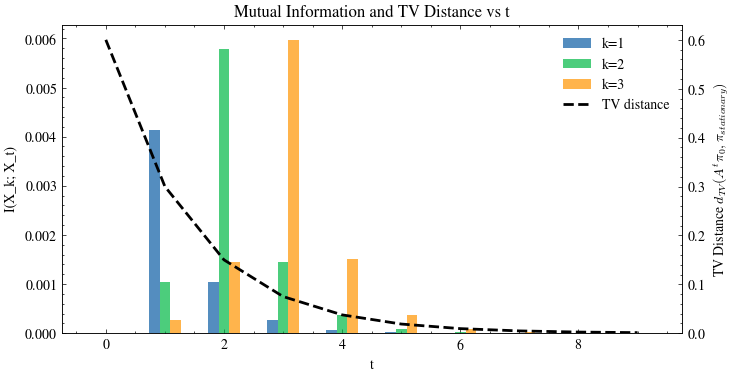

In [53]:
# Repeat the earlier plot but with TV distance to the stationary


fig, ax1 = plt.subplots(figsize=(8, 4))

# Plot TV distance first (so it appears in the background)
ax2 = ax1.twinx()
ax2.plot(ts, tv_distances, color='black', linewidth=2, linestyle='--', label="TV distance", zorder=1)
ax2.set_ylabel("TV Distance $d_{TV}(A^t\pi_0, \pi_{stationary})$", color='black')
ax2.tick_params(axis='y', labelcolor='black')

# Force right axis (ax2) to anchor zero *exactly* on x-axis
# This will align the 0 level of the TV axis with the x-axis
ax2.set_ylim(bottom=0)  # Set 0 at the x-axis (no gap)
yticks = ax2.get_yticks()
if yticks[0] > 0:
    ax2.set_yticks([0] + list(yticks))

# Bar plots for mutual information (plotted after, so they appear over the TV line)
bar_width = 0.18  # Or use whatever width was used earlier
for i, k in enumerate(ks):
    offset = (i - (len(ks) - 1) / 2) * bar_width
    ax1.bar(ts + offset, mi_values[k], width=bar_width, alpha=0.7, label=f"k={k}", zorder=2)
ax1.set_xlabel("t")
ax1.set_ylabel("I(X_k; X_t)")
ax1.set_title("Mutual Information and TV Distance vs t")
ax1.legend(loc="upper left")

# Add TV legend entry in the right place
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right")

plt.show()